In [25]:
# KOZMOS (YTÜ) ile Aspect-Based Duygu Analizi
# Branch: yontem_cozmos  |  Sorumlu: Ahmet Çağlar
!pip install transformers datasets scikit-learn seaborn wordcloud -q

In [26]:
DATA_PATH = "/content/"
import pandas as pd
import numpy as np

# utf-8-sig: Türkçe karakterlerin doğru okunması için
train_df = pd.read_csv(DATA_PATH + "train.csv", encoding="utf-8-sig")
test_df  = pd.read_csv(DATA_PATH + "test.csv",  encoding="utf-8-sig")
val_df   = pd.read_csv(DATA_PATH + "val.csv",   encoding="utf-8-sig")

print(f"Train: {train_df.shape}, Test: {test_df.shape}, Val: {val_df.shape}")
print(train_df["sentiment"].value_counts())

Train: (2350, 3), Test: (504, 3), Val: (504, 3)
sentiment
pozitif    1347
negatif     810
notr        193
Name: count, dtype: int64


In [27]:
#Label_encode + input formatı
LABEL_MAP = {"negatif":0 , "notr": 1, "pozitif":2}
INV_LABEL = {v:i for i, v in LABEL_MAP.items()}
for df in [train_df, val_df, test_df]:
    df["label"] = df["sentiment"].map(LABEL_MAP)
    df["input_text"] = df["yorum"].astype(str) + " [SEP] " + df["aspect"].astype(str)

print("Örnek input:")
print(train_df["input_text"].iloc[0])
print("Label:", train_df["label"].iloc[0])

Örnek input:
acil ihtiyacım olduğu için aldım genel olarak memnunum ince ve kibar bir tasarımı var kullanımı keyifli görsel olarak da hoş [SEP] genel
Label: 2


In [28]:
from sklearn.utils.class_weight import compute_class_weight
import torch

# Sınıflar dengesiz (notr çok az), balanced ağırlık hesaplıyoruz
classes = np.array([0, 1, 2])  # negatif=0, notr=1, pozitif=2
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values,
)
class_weights = torch.tensor(weights, dtype=torch.float)

print("Class weights:")
print(f"  negatif (0): {weights[0]:.3f}")
print(f"  notr    (1): {weights[1]:.3f}")
print(f"  pozitif (2): {weights[2]:.3f}")

Class weights:
  negatif (0): 0.967
  notr    (1): 4.059
  pozitif (2): 0.582


In [29]:
# model yüklemesi ve tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "ytu-ce-cosmos/turkish-small-bert-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Model:", MODEL_NAME)
print("Cihaz:", device)

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ytu-ce-cosmos/turkish-small-bert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: ytu-ce-cosmos/turkish-small-bert-uncased
Cihaz: cuda


In [30]:
#Veri seti sınıfı
from torch.utils.data import Dataset

class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df["input_text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ABSADataset(train_df, tokenizer)
val_dataset   = ABSADataset(val_df,   tokenizer)
test_dataset  = ABSADataset(test_df,  tokenizer)

In [31]:
#Fine-tuning
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score
from torch.nn import CrossEntropyLoss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "macro_f1":    f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

# Az temsil edilen notr sınıfı için ağırlıklı kayıp
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        loss    = CrossEntropyLoss(weight=class_weights.to(logits.device))(logits, labels)
        return (loss, outputs) if return_outputs else loss

SAVE_PATH = DATA_PATH + "kozmos_model/"

training_args = TrainingArguments(
    output_dir=SAVE_PATH,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Fine-tuning başlıyor... (max 10 epoch, patience=2)")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Fine-tuning başlıyor... (max 10 epoch, patience=2)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.071266,0.925191,0.740079,0.543963,0.735427
2,0.801017,0.778866,0.787698,0.611590,0.787861
3,0.702604,0.733094,0.787698,0.640855,0.795515
4,0.633620,0.710071,0.791667,0.655449,0.798956
5,0.533720,0.757276,0.805556,0.670274,0.807549
6,0.427177,0.747154,0.789683,0.666004,0.798125
7,0.450084,0.757303,0.789683,0.666090,0.796927


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias'].
There were unexpected keys in the checkp

TrainOutput(global_step=1029, training_loss=0.6655023471027816, metrics={'train_runtime': 76.1994, 'train_samples_per_second': 308.401, 'train_steps_per_second': 19.291, 'total_flos': 162654504768000.0, 'train_loss': 0.6655023471027816, 'epoch': 7.0})

In [32]:
#Test değerlendirmesi
from sklearn.metrics import classification_report, confusion_matrix

preds_output = trainer.predict(test_dataset)
y_pred_idx   = np.argmax(preds_output.predictions, axis=-1)
y_true_idx   = test_df["label"].values

y_pred = [INV_LABEL[i] for i in y_pred_idx]
y_true = [INV_LABEL[i] for i in y_true_idx]

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: %{acc*100:.2f}")
print(classification_report(
    y_true, y_pred,
    labels=["pozitif", "negatif", "notr"],
    target_names=["pozitif", "negatif", "notr"]
))

Test Accuracy: %79.37
              precision    recall  f1-score   support

     pozitif       0.87      0.86      0.87       289
     negatif       0.77      0.82      0.79       174
        notr       0.26      0.22      0.24        41

    accuracy                           0.79       504
   macro avg       0.64      0.63      0.63       504
weighted avg       0.79      0.79      0.79       504



In [33]:
# Kaydetme hücresi
test_df["tahmin"] = y_pred
test_df[["yorum", "aspect", "sentiment", "tahmin"]].to_csv(
    DATA_PATH + "kozmos_predictions.csv",
    index=False, encoding="utf-8-sig"
)
print("Tahminler kaydedildi.")

Tahminler kaydedildi.


In [34]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os

matplotlib.rcParams["font.family"] = "DejaVu Sans"   # Türkçe karakter sorunsuz
matplotlib.rcParams["axes.unicode_minus"] = False

VISUALS = DATA_PATH + "visuals_kozmos/"
os.makedirs(VISUALS, exist_ok=True)

ASPECTS = ["genel", "kargo", "kalite", "fiyat", "batarya", "ses_goruntu", "ambalaj"]
RENKLER = {"pozitif": "#2ecc71", "negatif": "#e74c3c", "notr": "#95a5a6"}

# test_df'te tahmin sütunu zaten var (Hücre 8'den). Garanti olsun diye:
test_df["tahmin"] = y_pred
print("Görselleştirme hazır. Kayıt klasörü:", VISUALS)


Görselleştirme hazır. Kayıt klasörü: /content/visuals_kozmos/


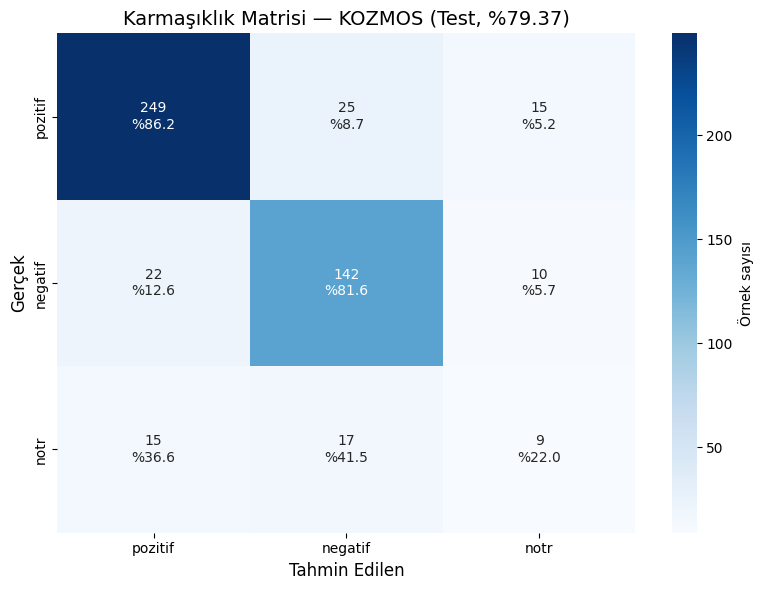

Kaydedildi: 01_karmasiklik_matrisi.png


In [35]:
from sklearn.metrics import confusion_matrix

labels_str = ["pozitif", "negatif", "notr"]
cm = confusion_matrix(y_true, y_pred, labels=labels_str)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100   # satır bazlı recall yüzdesi

annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n%{cm_pct[i, j]:.1f}"

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=labels_str, yticklabels=labels_str,
            cbar_kws={"label": "Örnek sayısı"})
plt.title("Karmaşıklık Matrisi — KOZMOS (Test, %79.37)", fontsize=14)
plt.xlabel("Tahmin Edilen", fontsize=12)
plt.ylabel("Gerçek", fontsize=12)
plt.tight_layout()
plt.savefig(VISUALS + "01_karmasiklik_matrisi.png", dpi=150)
plt.show()
print("Kaydedildi: 01_karmasiklik_matrisi.png")


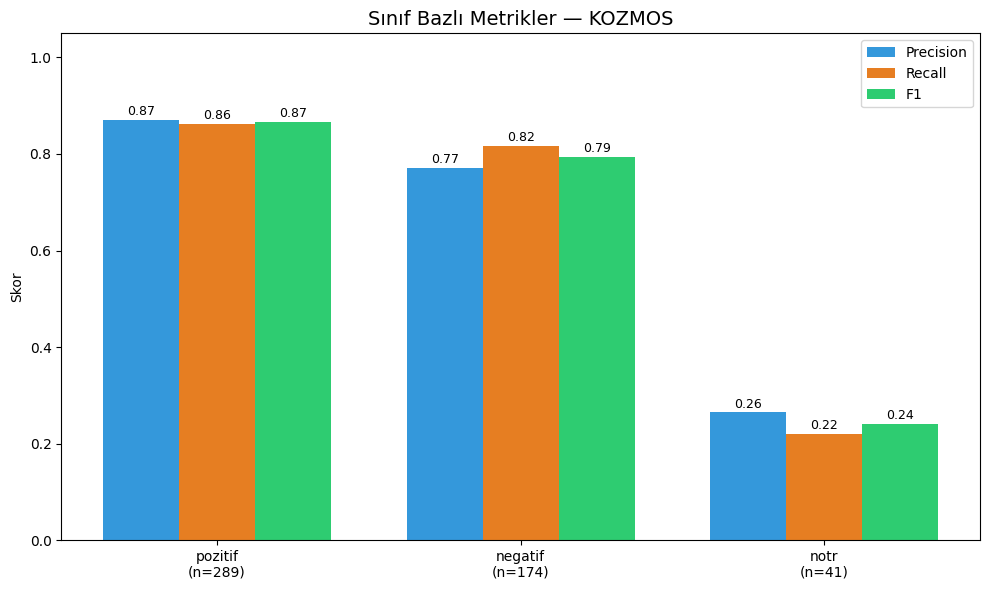

Kaydedildi: 02_sinif_metrikleri.png


In [36]:
from sklearn.metrics import precision_recall_fscore_support

p, r, f1, sup = precision_recall_fscore_support(
    y_true, y_pred, labels=labels_str, zero_division=0
)

x = np.arange(len(labels_str))
w = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - w, p,  w, label="Precision", color="#3498db")
plt.bar(x,     r,  w, label="Recall",    color="#e67e22")
plt.bar(x + w, f1, w, label="F1",        color="#2ecc71")

for i in range(len(labels_str)):
    for off, val in zip([-w, 0, w], [p[i], r[i], f1[i]]):
        plt.text(x[i] + off, val + 0.01, f"{val:.2f}", ha="center", fontsize=9)

plt.xticks(x, [f"{l}\n(n={s})" for l, s in zip(labels_str, sup)])
plt.ylim(0, 1.05)
plt.ylabel("Skor")
plt.title("Sınıf Bazlı Metrikler — KOZMOS", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS + "02_sinif_metrikleri.png", dpi=150)
plt.show()
print("Kaydedildi: 02_sinif_metrikleri.png")


/tmp/ipykernel_640/3449929869.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=test_df, x="aspect", order=asp_order, palette="Set2")


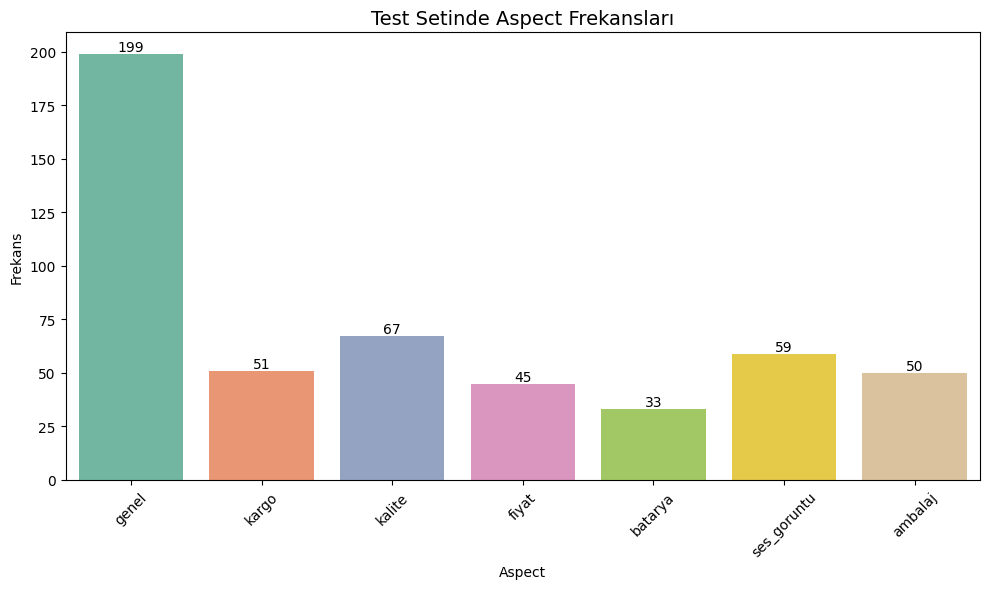

Kaydedildi: 03_aspect_frekanslari.png


In [37]:
asp_order = [a for a in ASPECTS if a in test_df["aspect"].values]

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=test_df, x="aspect", order=asp_order, palette="Set2")
for c in ax.containers:
    ax.bar_label(c, fontsize=10)
plt.title("Test Setinde Aspect Frekansları", fontsize=14)
plt.xlabel("Aspect"); plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(VISUALS + "03_aspect_frekanslari.png", dpi=150)
plt.show()
print("Kaydedildi: 03_aspect_frekanslari.png")


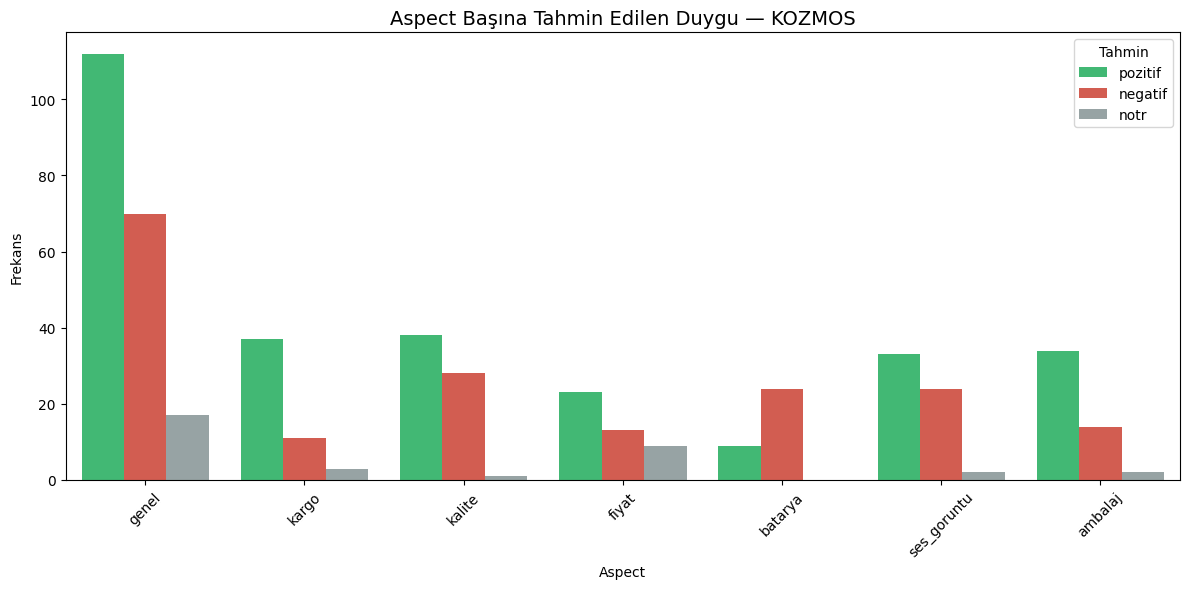

Kaydedildi: 04_aspect_sentiment_tahmin.png


In [38]:
plt.figure(figsize=(12, 6))
sns.countplot(data=test_df, x="aspect", hue="tahmin",
              order=asp_order, hue_order=["pozitif", "negatif", "notr"],
              palette=RENKLER)
plt.title("Aspect Başına Tahmin Edilen Duygu — KOZMOS", fontsize=14)
plt.xlabel("Aspect"); plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.legend(title="Tahmin")
plt.tight_layout()
plt.savefig(VISUALS + "04_aspect_sentiment_tahmin.png", dpi=150)
plt.show()
print("Kaydedildi: 04_aspect_sentiment_tahmin.png")


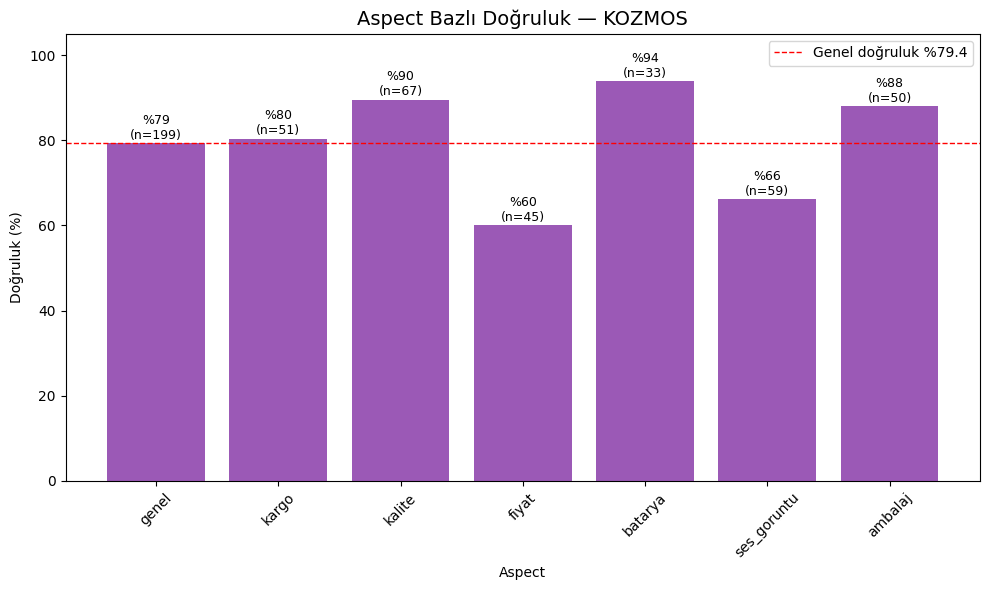

Kaydedildi: 05_aspect_dogruluk.png


In [39]:
test_df["dogru"] = (test_df["sentiment"] == test_df["tahmin"])
acc_by_aspect = test_df.groupby("aspect")["dogru"].mean().reindex(asp_order) * 100
n_by_aspect   = test_df.groupby("aspect").size().reindex(asp_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(acc_by_aspect.index, acc_by_aspect.values, color="#9b59b6")
for b, n in zip(bars, n_by_aspect.values):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             f"%{b.get_height():.0f}\n(n={n})", ha="center", fontsize=9)
plt.axhline(79.37, color="red", ls="--", lw=1, label="Genel doğruluk %79.4")
plt.ylim(0, 105)
plt.title("Aspect Bazlı Doğruluk — KOZMOS", fontsize=14)
plt.xlabel("Aspect"); plt.ylabel("Doğruluk (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS + "05_aspect_dogruluk.png", dpi=150)
plt.show()
print("Kaydedildi: 05_aspect_dogruluk.png")


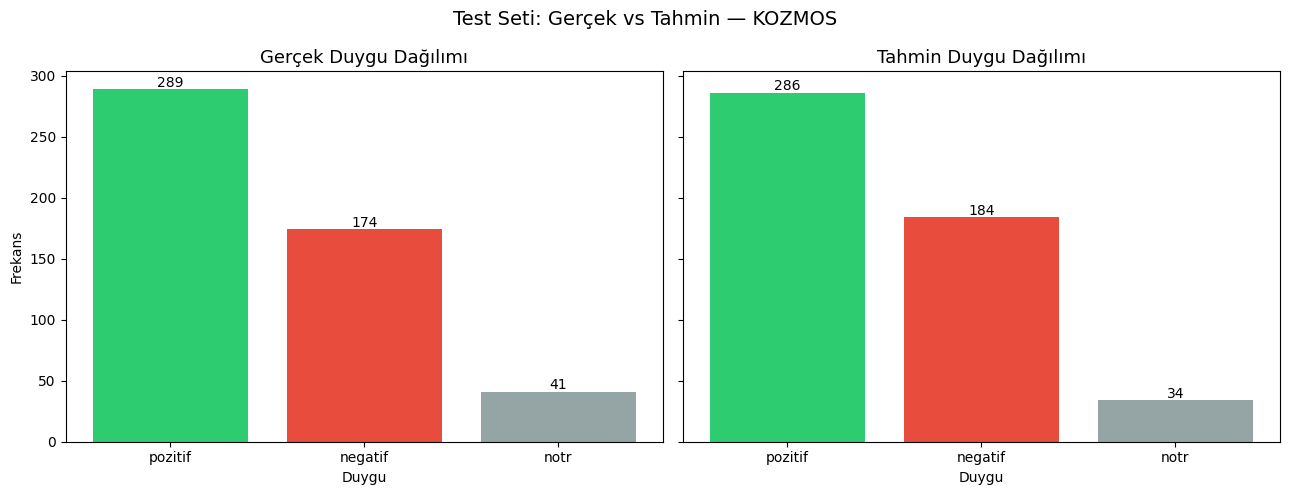

Kaydedildi: 06_gercek_vs_tahmin.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
order_s = ["pozitif", "negatif", "notr"]

for ax, col, baslik in zip(axes, ["sentiment", "tahmin"], ["Gerçek", "Tahmin"]):
    vc = test_df[col].value_counts().reindex(order_s)
    ax.bar(vc.index, vc.values, color=[RENKLER[s] for s in order_s])
    for i, v in enumerate(vc.values):
        ax.text(i, v + 2, str(v), ha="center", fontsize=10)
    ax.set_title(f"{baslik} Duygu Dağılımı", fontsize=13)
    ax.set_xlabel("Duygu")
axes[0].set_ylabel("Frekans")
plt.suptitle("Test Seti: Gerçek vs Tahmin — KOZMOS", fontsize=14)
plt.tight_layout()
plt.savefig(VISUALS + "06_gercek_vs_tahmin.png", dpi=150)
plt.show()
print("Kaydedildi: 06_gercek_vs_tahmin.png")


In [41]:
import shutil
from google.colab import files
shutil.make_archive("/content/visuals_kozmos", "zip", VISUALS)
files.download("/content/visuals_kozmos.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>